In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Makes charts look clean
sns.set_theme(style="whitegrid", palette="Blues_d")
plt.rcParams["figure.dpi"] = 130

In [13]:
df_monthly  = pd.read_csv("../outputs/monthly_revenue.csv")
df_rfm      = pd.read_csv("../outputs/rfm_segments.csv")
df_returns  = pd.read_csv("../outputs/category_returns.csv")
df_region   = pd.read_csv("../outputs/revenue_by_region.csv")

print("Monthly shape :", df_monthly.shape)
print("RFM shape     :", df_rfm.shape)
print("Returns shape :", df_returns.shape)
df_monthly.head()

Monthly shape : (23, 5)
RFM shape     : (96477, 9)
Returns shape : (53, 5)


,month,gmv,total_orders,aov,mom_growth_pct
0,2016-09,143.46,1,143.46,NaN
1,2016-10,46490.66,265,175.44,32306.71
2,2016-12,19.62,1,19.62,-99.96
3,2017-01,127482.37,750,169.98,649657.24
4,2017-02,271239.32,1653,164.09,112.77


In [14]:
total_gmv    = df_monthly["gmv"].sum()
avg_aov      = df_monthly["aov"].mean()
avg_growth   = df_monthly["mom_growth_pct"].mean()
total_orders = df_monthly["total_orders"].sum()

print("=" * 40)
print(f"  Total GMV         : R$ {total_gmv:,.0f}")
print(f"  Avg AOV           : R$ {avg_aov:,.2f}")
print(f"  Avg MoM Growth    : {avg_growth:.1f}%")
print(f"  Total Orders      : {total_orders:,}")
print("=" * 40)

  Total GMV         : R$ 15,419,774
  Avg AOV           : R$ 154.39
  Avg MoM Growth    : 31006.8%
  Total Orders      : 96,478


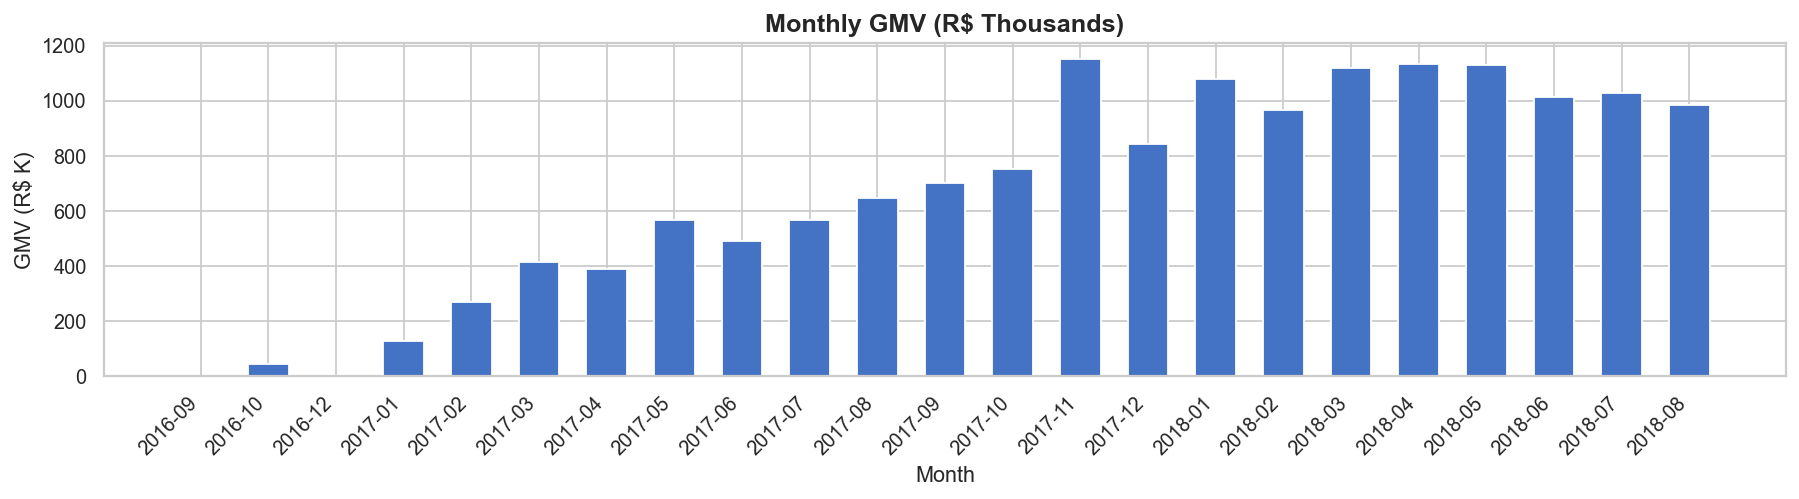

In [15]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(df_monthly["month"], df_monthly["gmv"] / 1_000, color="#4472C4", width=0.6)
ax.set_title("Monthly GMV (R$ Thousands)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("GMV (R$ K)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/gmv_trend.png", dpi=150)
plt.show()

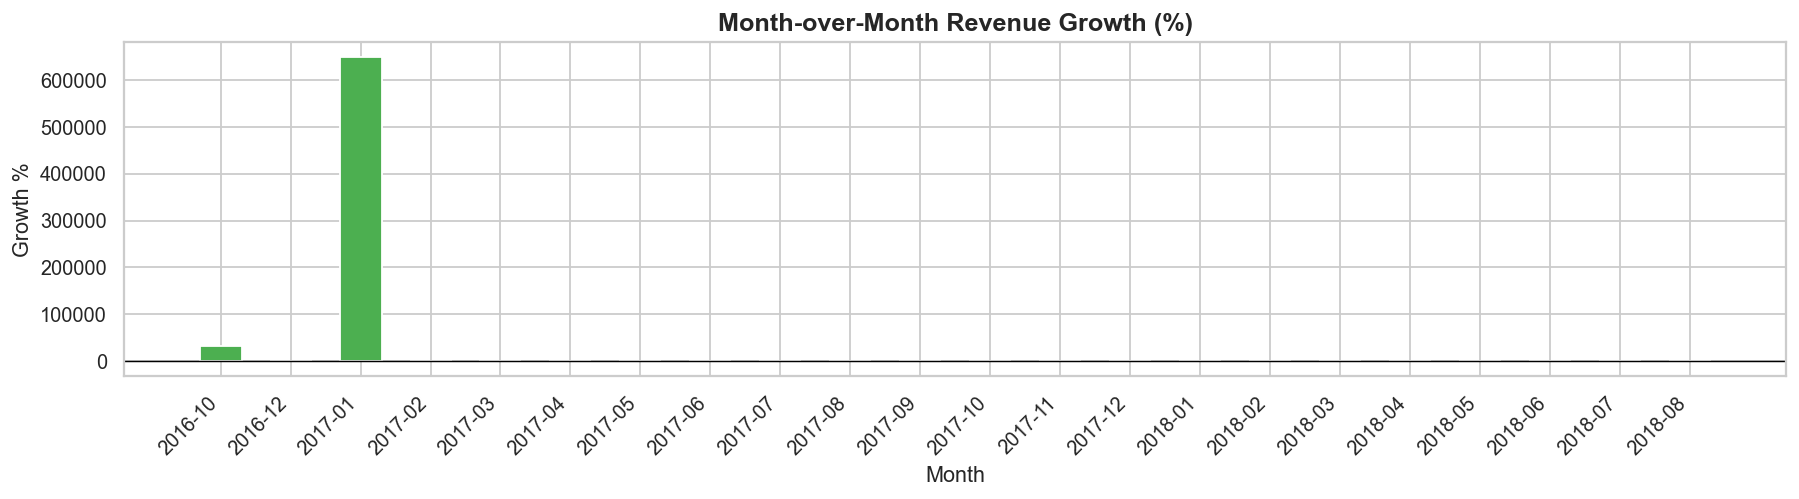

In [16]:
growth = df_monthly.dropna(subset=["mom_growth_pct"])

colors = ["#E05C5C" if x < 0 else "#4CAF50" for x in growth["mom_growth_pct"]]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(growth["month"], growth["mom_growth_pct"], color=colors, width=0.6)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Month-over-Month Revenue Growth (%)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Growth %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/mom_growth.png", dpi=150)
plt.show()

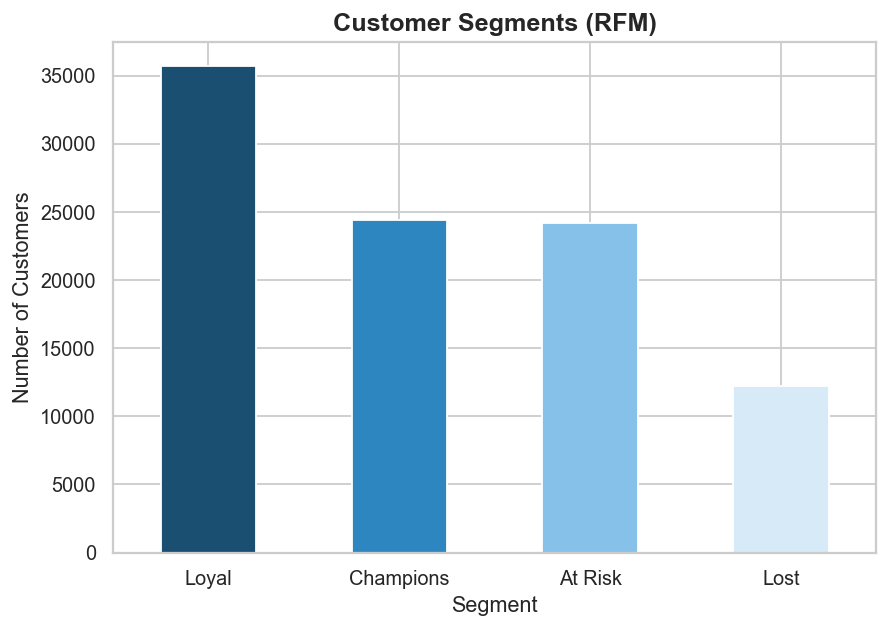

In [17]:
seg_counts = df_rfm["segment"].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
seg_counts.plot(kind="bar", color=["#1B4F72","#2E86C1","#85C1E9","#D6EAF8"], ax=ax)
ax.set_title("Customer Segments (RFM)", fontsize=14, fontweight="bold")
ax.set_xlabel("Segment"); ax.set_ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../outputs/rfm_segments.png", dpi=150)
plt.show()

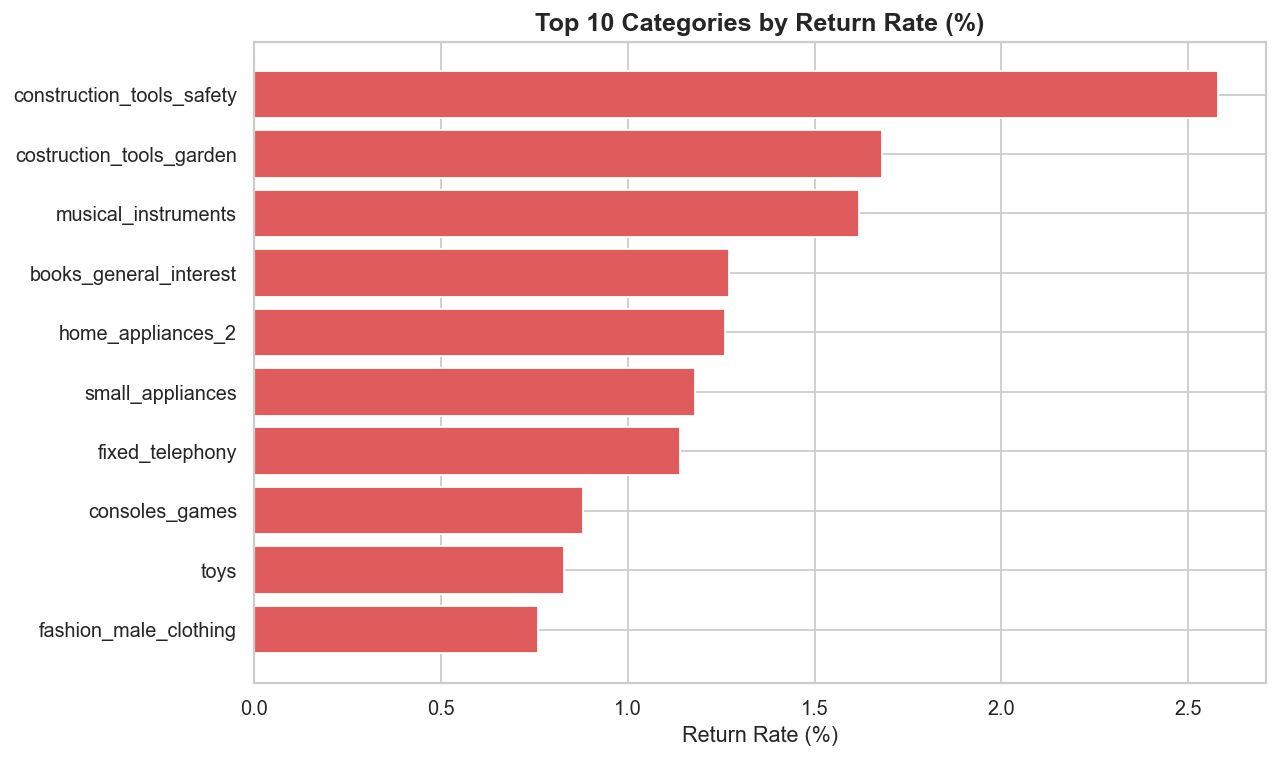

Top 3 highest-return categories account for 3.8% of all returns


In [18]:
top_returns = df_returns.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_returns["category"], top_returns["return_rate_pct"], color="#E05C5C")
ax.set_title("Top 10 Categories by Return Rate (%)", fontsize=14, fontweight="bold")
ax.set_xlabel("Return Rate (%)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/top_returns.png", dpi=150)
plt.show()

# The key insight for your resume bullet point:
bottom3 = df_returns.head(3)
total_pct = bottom3["pct_of_all_returns"].sum()
print(f"Top 3 highest-return categories account for {total_pct:.1f}% of all returns")

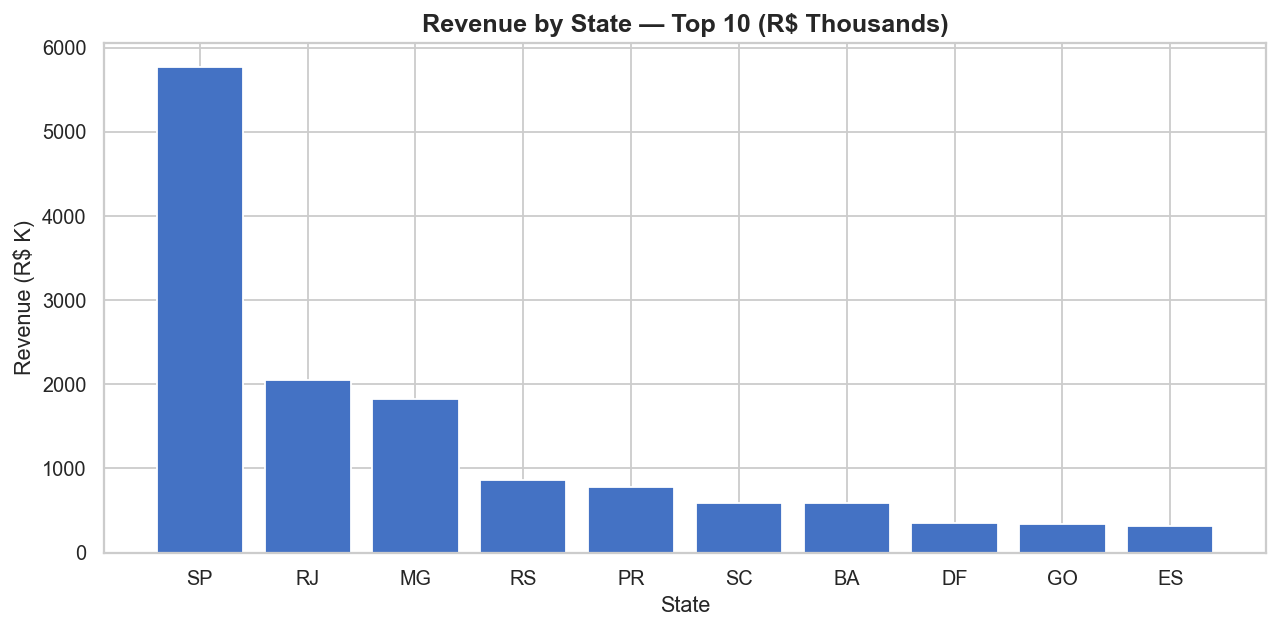

In [19]:
top_states = df_region.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(top_states["state"], top_states["revenue"] / 1_000, color="#4472C4")
ax.set_title("Revenue by State — Top 10 (R$ Thousands)", fontsize=14, fontweight="bold")
ax.set_xlabel("State"); ax.set_ylabel("Revenue (R$ K)")
plt.tight_layout()
plt.savefig("../outputs/revenue_by_state.png", dpi=150)
plt.show()